In [162]:
!pip install fastf1

In [163]:
import fastf1
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [164]:
print("\n🏎️  F1 Lap Time Predictor")
print("="*40)

#user input
season = int(input("Enter season (e.g., 2023, 2024): "))
round_num = input("Enter round number: ")

#if user input for round num is empty
if round_num.strip()=="":
  schedule = fastf1.get_event_schedule(season)
  round_num = len(schedule)
  print(f"Latest race: Round {round_num}")
else:
  round_num = int(round_num)

#loading the session (R=race)
print(f"\n📊 Loading season {season}, round {round_num}...")
session = fastf1.get_session(season, round_num,"R")
session.load(laps=True)



🏎️  F1 Lap Time Predictor
Enter season (e.g., 2023, 2024): 2024
Enter round number: 24


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
INFO:fastf1.fastf1.core:Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...



📊 Loading season 2024, round 24...


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	F

In [165]:
#data preprocessing

print("\n🧹 Cleaning data...")
laps = session.laps.copy() #get laps data

laps = laps.dropna(subset=["LapTime"])

laps = laps[laps["LapNumber"]>1] #remove lap 1

if "PitInTime" in laps.columns:
  laps = laps[laps["PitInTime"].isna()] #remove pit laps

laps["LapTimeSeconds"] = laps["LapTime"].dt.total_seconds() #convert time to secs

#remove outliers using IQR method
Q1 = laps["LapTimeSeconds"].quantile(0.25)
Q3 = laps["LapTimeSeconds"].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
lower = Q3+1.5*IQR
laps = laps[(laps['LapTimeSeconds'] >= lower) & (laps['LapTimeSeconds'] <= upper)]

print(f"✅ Cleaned data: {len(laps)} laps remaining")
laps.head()


🧹 Cleaning data...
✅ Cleaned data: 65 laps remaining


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds
1,0 days 01:00:22.535000,VER,1,0 days 00:01:54.938000,2.0,1.0,NaT,NaT,0 days 00:00:18.209000,0 days 00:00:54.569000,...,Red Bull Racing,0 days 00:58:27.597000,2024-12-08 13:05:14.814,126,11.0,False,,False,False,114.938
2,0 days 01:02:00.586000,VER,1,0 days 00:01:38.051000,3.0,1.0,NaT,NaT,0 days 00:00:23.196000,0 days 00:00:41.997000,...,Red Bull Racing,0 days 01:00:22.535000,2024-12-08 13:07:09.752,671,10.0,False,,False,False,98.051
29,0 days 01:43:00.437000,VER,1,0 days 00:01:59.495000,30.0,2.0,0 days 01:41:32.683000,NaT,0 days 00:00:49.136000,0 days 00:00:38.137000,...,Red Bull Racing,0 days 01:41:00.942000,2024-12-08 13:47:48.159,12,11.0,False,,False,False,119.495
59,0 days 01:00:11.831000,GAS,10,0 days 00:01:49.760000,2.0,1.0,NaT,NaT,0 days 00:00:18.158000,0 days 00:00:46.804000,...,Alpine,0 days 00:58:22.071000,2024-12-08 13:05:09.288,126,3.0,False,,False,False,109.760
60,0 days 01:01:54.668000,GAS,10,0 days 00:01:42.837000,3.0,1.0,NaT,NaT,0 days 00:00:25.771000,0 days 00:00:44.128000,...,Alpine,0 days 01:00:11.831000,2024-12-08 13:06:59.048,671,3.0,False,,False,False,102.837


In [166]:
#features

print("\n🔧 Creating features...")

#numerical features
features = pd.DataFrame()
features["LapNumber"] = laps["LapNumber"]
features["TyreLife"] = laps["TyreLife"].fillna(0) #0 for missing values
features['Stint'] = laps['Stint'].fillna(1)
features['Position'] = laps['Position'].fillna(20)

#one-hot encoding driver names
driver_dummies = pd.get_dummies(laps['Driver'], prefix='Driver')
features = pd.concat([features, driver_dummies], axis=1)

#one-hot encoding tyre compound
if 'Compound' in laps.columns:
    compound_dummies = pd.get_dummies(laps['Compound'], prefix='Compound')
    features = pd.concat([features, compound_dummies], axis=1)

target = laps["LapTimeSeconds"] #target variable
print(f"✅ Created {features.shape[1]} features")


🔧 Creating features...
✅ Created 26 features


In [167]:
#train model
print("\n🤖 Training model...")

#split data
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.2, random_state = 42)

#random forest
model = RandomForestRegressor(n_estimators = 100, max_depth = 10, random_state = 42)
model.fit(X_train, y_train)

#evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"\n📈 Model Performance:")
print(f"   Mean Absolute Error: {mae:.3f} seconds")
print(f"   R² Score: {r2:.3f}")


🤖 Training model...

📈 Model Performance:
   Mean Absolute Error: 3.373 seconds
   R² Score: 0.646


In [168]:
print("\n🔍 Most important factors:")
importance_df = pd.DataFrame({
    "Feature": features.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

for i, row in importance_df.head(5).iterrows():
    print(f"   {row["Feature"]}: {row["Importance"]:.2%}")


🔍 Most important factors:
   TyreLife: 47.19%
   LapNumber: 23.71%
   Position: 15.63%
   Stint: 7.15%
   Driver_LAW: 1.61%



📊 Generating visualizations...


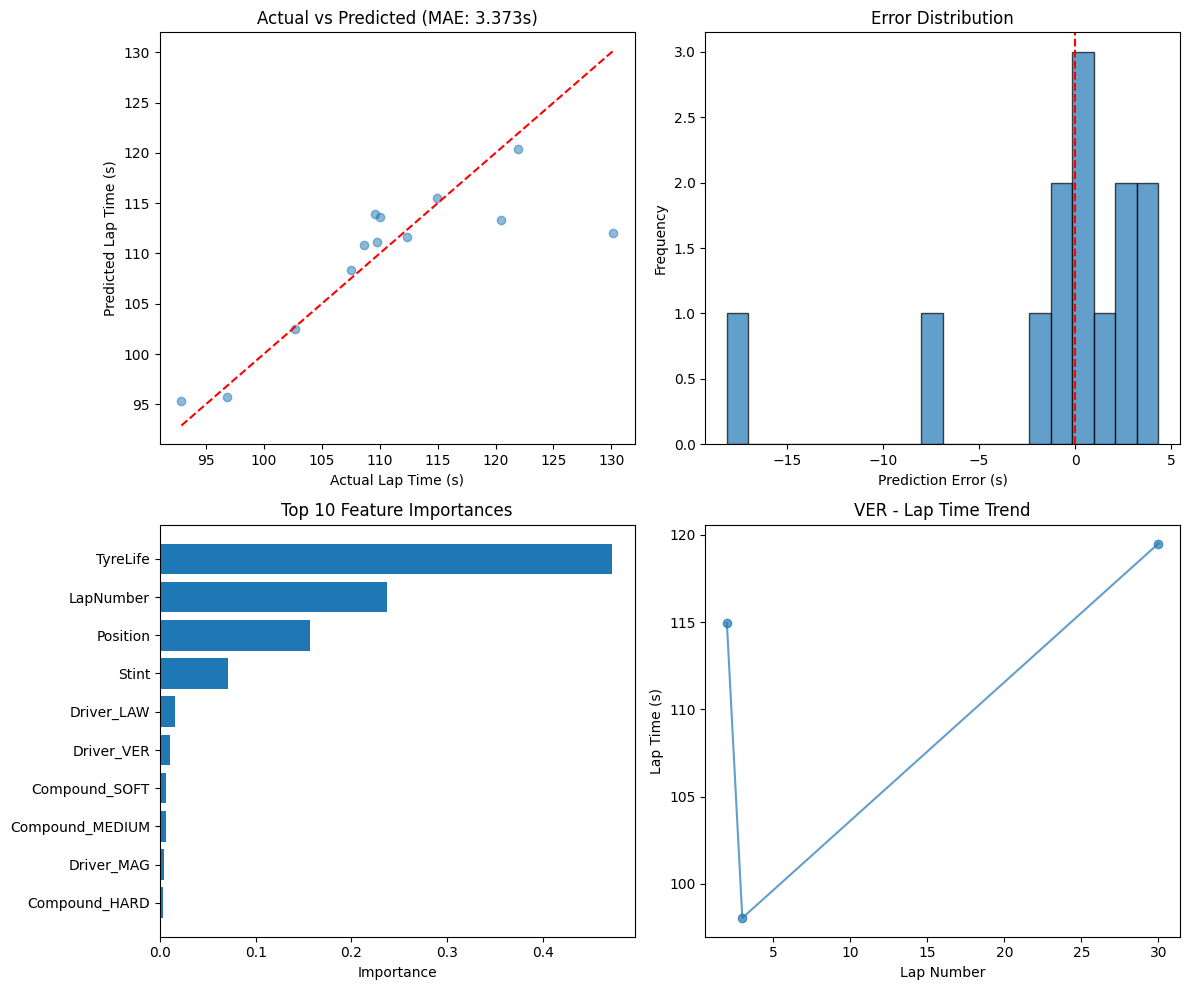

✅ Saved visualization as 'model_analysis.png'


In [169]:
#visualization
print("\n📊 Generating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Actual vs Predicted
axes[0,0].scatter(y_test, predictions, alpha=0.5)
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0,0].set_xlabel('Actual Lap Time (s)')
axes[0,0].set_ylabel('Predicted Lap Time (s)')
axes[0,0].set_title(f'Actual vs Predicted (MAE: {mae:.3f}s)')

# Plot 2: Error Distribution
errors = predictions - y_test
axes[0,1].hist(errors, bins=20, edgecolor='black', alpha=0.7)
axes[0,1].axvline(x=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Prediction Error (s)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Error Distribution')

# Plot 3: Top 10 Feature Importance
top_features = importance_df.head(10)
axes[1,0].barh(top_features['Feature'], top_features['Importance'])
axes[1,0].set_xlabel('Importance')
axes[1,0].set_title('Top 10 Feature Importances')
axes[1,0].invert_yaxis()

# Plot 4: Lap time trend (sample driver)
sample_driver = laps['Driver'].iloc[0]
driver_laps = laps[laps['Driver'] == sample_driver]
axes[1,1].plot(driver_laps['LapNumber'], driver_laps['LapTimeSeconds'], 'o-', alpha=0.7)
axes[1,1].set_xlabel('Lap Number')
axes[1,1].set_ylabel('Lap Time (s)')
axes[1,1].set_title(f'{sample_driver} - Lap Time Trend')

plt.tight_layout()
plt.savefig('model_analysis.png', dpi=150)
plt.show()
print("✅ Saved visualization as 'model_analysis.png'")

In [170]:
#make predictions
print("\n" + "="*40)
print("🎯 Make Your Own Prediction")
print("="*40)

print("\nEnter race conditions:")
lap = int(input("  Lap number: "))
tyre_life = int(input("  Tyre age (laps): "))
stint = int(input("  Stint number: "))
position = int(input("  Race position: "))
driver = input("  Driver code (e.g., VER, HAM, LEC): ").upper()
compound = input("  Compound (SOFT/MEDIUM/HARD): ").upper()

# Build prediction input with one-hot encoding
prediction_input = pd.DataFrame({
    'LapNumber': [lap],
    'TyreLife': [tyre_life],
    'Stint': [stint],
    'Position': [position]
})

# Add driver one-hot columns (set all to 0, then set selected driver to 1)
for col in features.columns:
    if col.startswith('Driver_'):
        prediction_input[col] = 0
driver_col = f'Driver_{driver}'
if driver_col in prediction_input.columns:
    prediction_input[driver_col] = 1

# Add compound one-hot columns
for col in features.columns:
    if col.startswith('Compound_'):
        prediction_input[col] = 0
compound_col = f'Compound_{compound}'
if compound_col in prediction_input.columns:
    prediction_input[compound_col] = 1

# Ensure column order matches training
prediction_input = prediction_input[features.columns]

pred_time = model.predict(prediction_input)[0]
print(f"\n⏱️  Predicted lap time: {pred_time:.3f} seconds")


🎯 Make Your Own Prediction

Enter race conditions:
  Lap number: 25
  Tyre age (laps): 12
  Stint number: 2
  Race position: 3
  Driver code (e.g., VER, HAM, LEC): ver
  Compound (SOFT/MEDIUM/HARD): soft

⏱️  Predicted lap time: 108.860 seconds


In [171]:
#save model
save = input("\n💾 Save model for later? (yes/no): ").lower()
if save == 'yes':
    import joblib
    joblib.dump(model, 'f1_model.pkl')
    joblib.dump(features.columns.tolist(), 'feature_columns.pkl')
    print("✅ Model saved as 'f1_model.pkl'")
    print("✅ Feature columns saved as 'feature_columns.pkl'")


💾 Save model for later? (yes/no): yes
✅ Model saved as 'f1_model.pkl'
✅ Feature columns saved as 'feature_columns.pkl'
